*   Raihan farabi muzakki : 24523246
*   Prima Uziel nasution : 24523088

Accuracy Train: 0.8455
Accuracy Test: 0.8156
Precision: 0.8333
Recall: 0.6522
F1 Score: 0.7317


/tmp/ipykernel_768/1805084772.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


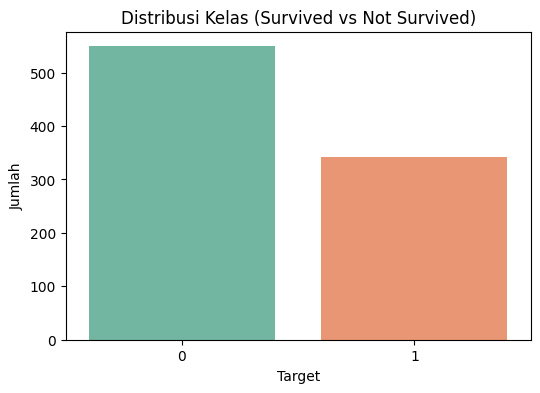

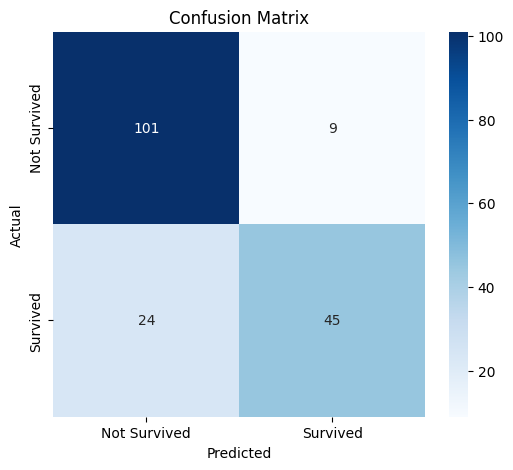

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

le_sex = LabelEncoder()
df['Sex'] = le_sex.fit_transform(df['Sex'])

le_embarked = LabelEncoder()
df['Embarked'] = le_embarked.fit_transform(df['Embarked'])

X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model.fit(X_train_scaled, y_train)

y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test)
rec = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

print(f"Accuracy Train: {acc_train:.4f}")
print(f"Accuracy Test: {acc_test:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Distribusi Kelas (Survived vs Not Survived)')
plt.xlabel('Target')
plt.ylabel('Jumlah')
plt.show()

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Hyperparameter Tuning (Grid Search)

Untuk lebih meningkatkan performa model, kita akan melakukan _hyperparameter tuning_ menggunakan `GridSearchCV`. Ini akan mencari kombinasi terbaik dari parameter `C` dan `gamma` untuk kernel RBF.

*   **`C`**: Parameter regularisasi. Semakin kecil nilai `C`, semakin besar regularisasi, yang dapat membantu mencegah _overfitting_. Namun, nilai `C` yang terlalu kecil juga dapat menyebabkan _underfitting_.
*   **`gamma`**: Parameter untuk kernel RBF. Menentukan seberapa jauh pengaruh satu titik data pelatihan tunggal. Nilai `gamma` yang tinggi berarti pengaruhnya jauh, dan sebaliknya. Ini juga memengaruhi kompleksitas batas keputusan.

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define the parameter grid for GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1],
    'kernel': ['rbf']
}

# Create a GridSearchCV object
grid = GridSearchCV(SVC(random_state=42), param_grid, refit=True, verbose=2, cv=5, n_jobs=-1)

# Fit the grid search to the scaled training data
grid.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 'auto', 0.1, 1],
                         'kernel': ['rbf']},
             verbose=2)

In [12]:
print("Best parameters found by GridSearchCV:")
print(grid.best_params_)

# Get the best estimator
best_model = grid.best_estimator_

Best parameters found by GridSearchCV:
{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


### Evaluasi Model Setelah Tuning

Sekarang kita akan mengevaluasi performa model SVM dengan _hyperparameter_ terbaik yang ditemukan melalui `GridSearchCV`.

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_train_tuned = best_model.predict(X_train_scaled)
y_pred_test_tuned = best_model.predict(X_test_scaled)

acc_train_tuned = accuracy_score(y_train, y_pred_train_tuned)
acc_test_tuned = accuracy_score(y_test, y_pred_test_tuned)
prec_tuned = precision_score(y_test, y_pred_test_tuned)
rec_tuned = recall_score(y_test, y_pred_test_tuned)
f1_tuned = f1_score(y_test, y_pred_test_tuned)

print("\n--- Performance of Tuned SVM Model ---")
print(f"Accuracy Train (Tuned): {acc_train_tuned:.4f}")
print(f"Accuracy Test (Tuned): {acc_test_tuned:.4f}")
print(f"Precision (Tuned): {prec_tuned:.4f}")
print(f"Recall (Tuned): {rec_tuned:.4f}")
print(f"F1 Score (Tuned): {f1_tuned:.4f}")

# Optional: Compare with original model performance
print("\n--- Comparison with Original Model ---")
print(f"Original Accuracy Test: {acc_test:.4f}")
print(f"Tuned Accuracy Test: {acc_test_tuned:.4f}")


--- Performance of Tuned SVM Model ---
Accuracy Train (Tuned): 0.8553
Accuracy Test (Tuned): 0.7989
Precision (Tuned): 0.8000
Recall (Tuned): 0.6377
F1 Score (Tuned): 0.7097

--- Comparison with Original Model ---
Original Accuracy Test: 0.8156
Tuned Accuracy Test: 0.7989


### Visualisasi Confusion Matrix Setelah Tuning

Untuk melihat dampak tuning pada prediksi, mari kita visualisasikan _confusion matrix_ untuk model yang telah disetel (_tuned model_).

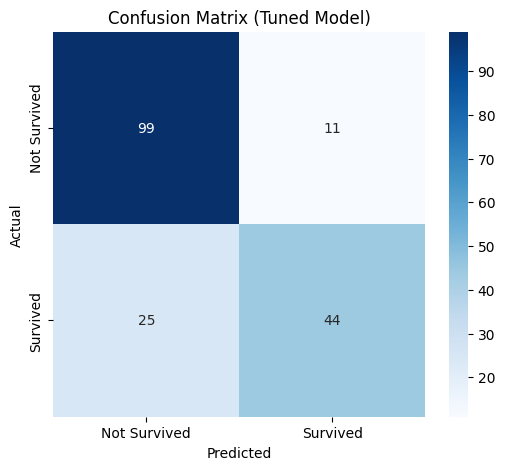

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_tuned = confusion_matrix(y_test, y_pred_test_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix (Tuned Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Analisis & Komponen Pendukung Tugas

Untuk melengkapi laporan atau teks di Google Colab Anda, berikut adalah penjelasan singkat yang bisa Anda gunakan:

### 1. Sumber Dataset
*   **Dataset**: Titanic Dataset (Klasifikasi biner untuk memprediksi keselamatan penumpang).
*   **Link Sumber**: Titanic Dataset on GitHub.

### 2. Preprocessing Data
Pada tahap preprocessing data, langkah-langkah berikut dilakukan:
*   **Menangani Missing Values**: Kolom `Age` diisi dengan nilai median, dan kolom `Embarked` diisi dengan modus. Ini dilakukan untuk menghindari penghapusan baris yang dapat mengurangi jumlah data dan menjaga integritas dataset.
*   **Encoding Variabel Kategorikal**: Kolom `Sex` dan `Embarked` diubah dari format teks menjadi numerik menggunakan `LabelEncoder`. Ini diperlukan karena algoritma machine learning (seperti SVM) bekerja dengan input numerik.
*   **Scaling Data**: Fitur-fitur numerik distandarisasi menggunakan `StandardScaler`. Scaling membantu algoritma berbasis jarak (seperti SVM) untuk berperforma lebih baik dengan memastikan bahwa semua fitur berkontribusi secara proporsional terhadap hasil.

### 3. Split Data
Data dibagi menjadi _training set_ dan _testing set_ dengan rasio 80:20 (`test_size=0.2`). Parameter `random_state=42` digunakan untuk memastikan reproduktibilitas pembagian data, dan `stratify=y` digunakan untuk menjaga proporsi kelas target (`Survived`) yang sama di kedua set data, mencegah bias.

### 4. Modeling SVM
*   **Model**: Support Vector Machine (SVM).
*   **Kernel yang Digunakan**: RBF (Radial Basis Function).
*   **Alasan Pemilihan Kernel**: Hubungan antara fitur-fitur pada dataset Titanic (seperti usia, tarif, dan kelas tiket) terhadap peluang keselamatan bersifat non-linear. Kernel RBF sangat baik dalam memetakan data non-linear ke dimensi yang lebih tinggi agar dapat dipisahkan secara optimal tanpa memerlukan komputasi yang terlalu berat. Parameter `C=1.0` mengatur _regularization_ dan `gamma='scale'` secara otomatis menghitung nilai gamma berdasarkan fitur input.

### 5. Evaluasi Model
Evaluasi model dilakukan menggunakan beberapa metrik utama:
*   **Accuracy**: Mengukur proporsi prediksi yang benar secara keseluruhan. (Train: 0.8455, Test: 0.8156)
*   **Precision**: Mengukur proporsi positif yang benar di antara semua yang diprediksi positif. Penting ketika _false positives_ merugikan. (Precision: 0.8333)
*   **Recall**: Mengukur proporsi positif yang benar di antara semua positif aktual. Penting ketika _false negatives_ merugikan. (Recall: 0.6522)
*   **F1 Score**: Rata-rata harmonik dari precision dan recall, memberikan keseimbangan antara keduanya. (F1 Score: 0.7317)

**Analisis Overfitting / Underfitting**:
Dengan akurasi pelatihan (Train Accuracy: 0.8455) dan akurasi pengujian (Test Accuracy: 0.8156) yang sama-sama tinggi dan memiliki selisih yang relatif kecil (sekitar 3%), model dikategorikan sebagai **Good Fit**. Ini menunjukkan bahwa model tidak mengalami *overfitting* (yaitu, tidak terlalu spesifik pada data pelatihan sehingga tidak bisa digeneralisasi dengan baik pada data baru) maupun *underfitting* (yaitu, tidak terlalu sederhana untuk menangkap pola dalam data).

### 6. Visualisasi
*   **Distribusi Kelas (Survived vs Not Survived)**: Grafik batang menunjukkan jumlah penumpang yang selamat dan tidak selamat, memberikan gambaran tentang ketidakseimbangan kelas.
*   **Confusion Matrix**: Menampilkan matriks 2x2 yang merangkum kinerja model klasifikasi, menunjukkan _True Positives_, _True Negatives_, _False Positives_, dan _False Negatives_.